<a href="https://colab.research.google.com/github/rampellisaieshwar/Calculator/blob/main/Untitled13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Develop a credit risk assessment model using a specified Kaggle dataset, involving data cleaning, preprocessing (handling categorical features and scaling numerical ones), training an XGBoost or Random Forest classifier, evaluating its performance with a focus on recall, and documenting the entire process.

## Data Acquisition

### Subtask:
Download the specified "Credit Risk Assessment" dataset from Kaggle and load it into a pandas DataFrame within the Jupyter Notebook. The user will provide the direct link and the initial code block.


```markdown
### Loading the Credit Risk Assessment Dataset

To proceed with the data loading, it is assumed that the "Credit Risk Assessment" dataset has been downloaded from Kaggle. If the dataset was downloaded as a CSV file, please ensure it's placed in the same directory as this notebook, or update the file path accordingly in the code block below. If the provided link is a direct download link to a CSV, `pd.read_csv()` can often handle it directly.
```

# Task
Load the 'train-FIN_ANA_DATA .xls' and 'test-FIN_ANA_DATA .xls' datasets into pandas DataFrames, and display their first 5 rows and concise summaries.

## Data Acquisition

### Subtask:
Load the provided 'train-FIN_ANA_DATA .xls' and 'test-FIN_ANA_DATA .xls' datasets into pandas DataFrames. Display their initial rows and concise summaries to understand their structure and content.


**Reasoning**:
To load the Excel files into pandas DataFrames and display their initial rows and summaries, I need to import pandas, use `pd.read_excel()` for each file, and then call `.head()` and `.info()` methods.



In [3]:
import pandas as pd

# Load the training dataset
train_df = pd.read_excel('/content/train-FIN_ANA_DATA .xls')
print("Train DataFrame - First 5 rows:")
print(train_df.head())
print("\nTrain DataFrame - Info:")
train_df.info()

# Load the test dataset
test_df = pd.read_excel('/content/test-FIN_ANA_DATA .xls')
print("\nTest DataFrame - First 5 rows:")
print(test_df.head())
print("\nTest DataFrame - Info:")
test_df.info()

Train DataFrame - First 5 rows:
        ACC_NO  INVESTMENT_TOTAL  ACCCURRENTBALANCE INF_MARITAL_STATUS  \
0  27010017245          10720596             585913                  M   
1  27010017436          43455000             585913                  M   
2  27010017458          22012402              68348                  M   
3  27010017493           4893983                  0                  M   
4  27010017515          46254814              68348                  M   

  INF_GENDER  INSTALL_SIZE  DUE_PAYMENT COMPENSATION_CHARGED CLIENT_TYPE  \
0          F           0.0            0                    N  Semi-urban   
1          F           0.0            0                    N  Semi-urban   
2          F           0.0      2744483                    N       Rural   
3          M           0.0            0                    N  Semi-urban   
4          F           0.0            0                    N       Rural   

  QUALITY_OF_LOAN REPAY_MODE  
0               G          N  
1   

## Data Cleaning

### Subtask:
Perform data cleaning by identifying and handling missing values (e.g., using median imputation for numerical columns) and removing any duplicate entries from the dataset.


**Reasoning**:
The first step is to identify and count missing values in both `train_df` and `test_df` to understand the data's completeness.



In [4]:
print("Missing values in Train DataFrame:\n", train_df.isnull().sum())
print("\nMissing values in Test DataFrame:\n", test_df.isnull().sum())

Missing values in Train DataFrame:
 ACC_NO                    0
INVESTMENT_TOTAL          0
ACCCURRENTBALANCE         0
INF_MARITAL_STATUS        2
INF_GENDER                2
INSTALL_SIZE            838
DUE_PAYMENT               0
COMPENSATION_CHARGED      2
CLIENT_TYPE             103
QUALITY_OF_LOAN           0
REPAY_MODE                0
dtype: int64

Missing values in Test DataFrame:
 ACC_NO                   0
INVESTMENT_TOTAL         0
ACCCURRENTBALANCE        0
INF_MARITAL_STATUS       0
INF_GENDER               0
INSTALL_SIZE             1
DUE_PAYMENT              0
COMPENSATION_CHARGED     0
CLIENT_TYPE             79
QUALITY_OF_LOAN          0
REPAY_MODE               0
dtype: int64


**Reasoning**:
Based on the identified missing values, I will now impute the numerical column 'INSTALL_SIZE' with its median for both train and test dataframes, and then impute the categorical columns 'INF_MARITAL_STATUS', 'INF_GENDER', 'COMPENSATION_CHARGED', and 'CLIENT_TYPE' with their respective modes in the training dataframe. For the test dataframe, I will impute 'CLIENT_TYPE' with its mode.



In [5]:
print("Before imputation:")
print("Train DataFrame missing values:\n", train_df.isnull().sum())
print("Test DataFrame missing values:\n", test_df.isnull().sum())

# Impute numerical column 'INSTALL_SIZE' with median for both train and test DataFrames
median_install_size_train = train_df['INSTALL_SIZE'].median()
median_install_size_test = test_df['INSTALL_SIZE'].median()

train_df['INSTALL_SIZE'].fillna(median_install_size_train, inplace=True)
test_df['INSTALL_SIZE'].fillna(median_install_size_test, inplace=True)

# Impute categorical columns in train_df with mode
for col in ['INF_MARITAL_STATUS', 'INF_GENDER', 'COMPENSATION_CHARGED', 'CLIENT_TYPE']:
    if train_df[col].isnull().any():
        mode_val = train_df[col].mode()[0]
        train_df[col].fillna(mode_val, inplace=True)

# Impute 'CLIENT_TYPE' in test_df with mode
if test_df['CLIENT_TYPE'].isnull().any():
    mode_client_type_test = test_df['CLIENT_TYPE'].mode()[0]
    test_df['CLIENT_TYPE'].fillna(mode_client_type_test, inplace=True)


print("\nAfter imputation:")
print("Train DataFrame missing values:\n", train_df.isnull().sum())
print("Test DataFrame missing values:\n", test_df.isnull().sum())

Before imputation:
Train DataFrame missing values:
 ACC_NO                    0
INVESTMENT_TOTAL          0
ACCCURRENTBALANCE         0
INF_MARITAL_STATUS        2
INF_GENDER                2
INSTALL_SIZE            838
DUE_PAYMENT               0
COMPENSATION_CHARGED      2
CLIENT_TYPE             103
QUALITY_OF_LOAN           0
REPAY_MODE                0
dtype: int64
Test DataFrame missing values:
 ACC_NO                   0
INVESTMENT_TOTAL         0
ACCCURRENTBALANCE        0
INF_MARITAL_STATUS       0
INF_GENDER               0
INSTALL_SIZE             1
DUE_PAYMENT              0
COMPENSATION_CHARGED     0
CLIENT_TYPE             79
QUALITY_OF_LOAN          0
REPAY_MODE               0
dtype: int64

After imputation:
Train DataFrame missing values:
 ACC_NO                  0
INVESTMENT_TOTAL        0
ACCCURRENTBALANCE       0
INF_MARITAL_STATUS      0
INF_GENDER              0
INSTALL_SIZE            0
DUE_PAYMENT             0
COMPENSATION_CHARGED    0
CLIENT_TYPE             0

/tmp/ipykernel_334/1930890074.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['INSTALL_SIZE'].fillna(median_install_size_train, inplace=True)
/tmp/ipykernel_334/1930890074.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

**Reasoning**:
The previous step successfully imputed missing values. The next logical step, as per the subtask instructions, is to identify and remove any duplicate rows from both `train_df` and `test_df` and display the row counts before and after the operation.



In [6]:
print("Train DataFrame - Rows before dropping duplicates:", len(train_df))
train_df.drop_duplicates(inplace=True)
print("Train DataFrame - Rows after dropping duplicates:", len(train_df))

print("\nTest DataFrame - Rows before dropping duplicates:", len(test_df))
test_df.drop_duplicates(inplace=True)
print("Test DataFrame - Rows after dropping duplicates:", len(test_df))

Train DataFrame - Rows before dropping duplicates: 37408
Train DataFrame - Rows after dropping duplicates: 37408

Test DataFrame - Rows before dropping duplicates: 4310
Test DataFrame - Rows after dropping duplicates: 4310


## Preprocessing

### Subtask:
Prepare the data for model training. This includes converting categorical text features (e.g., 'Home Owner') into numerical representations (one-hot encoding or label encoding) and scaling numerical features to prevent bias using scikit-learn.


**Reasoning**:
The first step in preprocessing is to separate the features (X) from the target variable (y) for both the training and test datasets. The target variable is 'QUALITY_OF_LOAN', which will be extracted, and the 'ACC_NO' column will be dropped as it's an identifier and not a feature.



In [7]:
y_train = train_df['QUALITY_OF_LOAN']
X_train = train_df.drop(columns=['QUALITY_OF_LOAN', 'ACC_NO'])

y_test = test_df['QUALITY_OF_LOAN']
X_test = test_df.drop(columns=['QUALITY_OF_LOAN', 'ACC_NO'])

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (37408, 9)
Shape of y_train: (37408,)
Shape of X_test: (4310, 9)
Shape of y_test: (4310,)


**Reasoning**:
Based on the subtask, I will now identify categorical columns that are binary and use `LabelEncoder` from `sklearn.preprocessing` to convert them into numerical representations for both training and test data.



In [8]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import pandas as pd

# Identify binary categorical columns
binary_cols = ['INF_MARITAL_STATUS', 'INF_GENDER', 'COMPENSATION_CHARGED', 'REPAY_MODE']

# Apply LabelEncoder to binary categorical columns
le = LabelEncoder()
for col in binary_cols:
    # Fit on the combined data to ensure consistent encoding across train and test
    # Although fitting on train and transforming both is more common, for LabelEncoder on binary
    # columns, ensuring all unique values are seen is crucial. If a value exists in test but not train,
    # fit_transform on train then transform on test might fail or give inconsistent results.
    # However, to strictly follow "fit on train then transform both", we can check common categories.
    # For simplicity and given the typical binary values, fitting individually should be fine if unique values are consistent.
    # A safer approach for robust production would be to combine, fit, then split.

    # For this specific step, we will apply fit_transform on train and then transform on test for consistency
    # with standard preprocessing practices, assuming categories are shared or handling errors appropriately.

    # As the subtask explicitly mentions applying to both, and given these are binary, we expect the categories to be consistent.
    # If not, one might consider combining before fitting or handling errors explicitly.
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print("LabelEncoder applied to binary columns in X_train:")
print(X_train[binary_cols].head())
print("\nLabelEncoder applied to binary columns in X_test:")
print(X_test[binary_cols].head())

LabelEncoder applied to binary columns in X_train:
   INF_MARITAL_STATUS  INF_GENDER  COMPENSATION_CHARGED  REPAY_MODE
0                   0           0                     0           1
1                   0           0                     0           1
2                   0           0                     0           1
3                   0           1                     0           1
4                   0           0                     0           1

LabelEncoder applied to binary columns in X_test:
   INF_MARITAL_STATUS  INF_GENDER  COMPENSATION_CHARGED  REPAY_MODE
0                   0           1                     0           1
1                   0           1                     0           1
2                   0           1                     0           1
3                   0           1                     0           1
4                   0           1                     0           1


**Reasoning**:
The previous `OneHotEncoder` application failed because the 'CLIENT_TYPE' column contained mixed data types, specifically integers and strings, which the encoder cannot handle. To resolve this, I will explicitly convert the 'CLIENT_TYPE' column to string type (`.astype(str)`) before applying the `OneHotEncoder`.



In [10]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Identify non-binary categorical columns
non_binary_cols = ['CLIENT_TYPE']

# Ensure the column is of string type before applying OneHotEncoder
X_train[non_binary_cols] = X_train[non_binary_cols].astype(str)
X_test[non_binary_cols] = X_test[non_binary_cols].astype(str)

# Apply OneHotEncoder to non-binary categorical columns
X_train_ohe = ohe.fit_transform(X_train[non_binary_cols])
X_test_ohe = ohe.transform(X_test[non_binary_cols])

# Get feature names for the new one-hot encoded columns
ohe_feature_names = ohe.get_feature_names_out(non_binary_cols)

# Convert to DataFrame
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_feature_names, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_feature_names, index=X_test.index)

# Drop original non-binary columns and concatenate one-hot encoded columns
X_train = X_train.drop(columns=non_binary_cols)
X_test = X_test.drop(columns=non_binary_cols)

X_train = pd.concat([X_train, X_train_ohe_df], axis=1)
X_test = pd.concat([X_test, X_test_ohe_df], axis=1)

print("OneHotEncoder applied to non-binary categorical columns in X_train. New shape:", X_train.shape)
print(X_train.head())
print("\nOneHotEncoder applied to non-binary categorical columns in X_test. New shape:", X_test.shape)
print(X_test.head())

OneHotEncoder applied to non-binary categorical columns in X_train. New shape: (37408, 12)
   INVESTMENT_TOTAL  ACCCURRENTBALANCE  INF_MARITAL_STATUS  INF_GENDER  \
0          10720596             585913                   0           0   
1          43455000             585913                   0           0   
2          22012402              68348                   0           0   
3           4893983                  0                   0           1   
4          46254814              68348                   0           0   

   INSTALL_SIZE  DUE_PAYMENT  COMPENSATION_CHARGED  REPAY_MODE  CLIENT_TYPE_0  \
0           0.0            0                     0           1            0.0   
1           0.0            0                     0           1            0.0   
2           0.0      2744483                     0           1            0.0   
3           0.0            0                     0           1            0.0   
4           0.0            0                     0         

**Reasoning**:
Now that categorical features have been encoded, the next step is to identify the numerical columns and apply `StandardScaler` to them to prevent bias, fitting on the training data and transforming both training and test sets.



In [11]:
numerical_cols = ['INVESTMENT_TOTAL', 'ACCCURRENTBALANCE', 'INSTALL_SIZE', 'DUE_PAYMENT']

# Apply StandardScaler to numerical columns
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("StandardScaler applied to numerical columns in X_train. First 5 rows:")
print(X_train[numerical_cols].head())
print("\nStandardScaler applied to numerical columns in X_test. First 5 rows:")
print(X_test[numerical_cols].head())

print("\nFinal X_train shape after scaling:", X_train.shape)
print("Final X_test shape after scaling:", X_test.shape)

StandardScaler applied to numerical columns in X_train. First 5 rows:
   INVESTMENT_TOTAL  ACCCURRENTBALANCE  INSTALL_SIZE  DUE_PAYMENT
0          0.173125          -0.094479     -0.068089    -0.085296
1          1.427878          -0.094479     -0.068089    -0.085296
2          0.605955          -0.177567     -0.068089     0.537588
3         -0.050217          -0.188540     -0.068089    -0.085296
4          1.535198          -0.177567     -0.068089    -0.085296

StandardScaler applied to numerical columns in X_test. First 5 rows:
   INVESTMENT_TOTAL  ACCCURRENTBALANCE  INSTALL_SIZE  DUE_PAYMENT
0         -0.213211          -0.188373     -0.068089     0.005488
1         -0.217413          -0.187848     -0.068089     0.008792
2         -0.213560          -0.187848     -0.068089    -0.014282
3         -0.162402          -0.187719     -0.068089    -0.085296
4         -0.175066          -0.188092     -0.068089    -0.085296

Final X_train shape after scaling: (37408, 12)
Final X_test shape a

## Model Training

### Subtask:
Train an XGBoost classifier on the preprocessed training data.


**Reasoning**:
The `ValueError` 'y contains previously unseen labels: SS' indicates that the `LabelEncoder` fitted on `y_train` did not encounter the label 'SS', which is present in `y_test`. To fix this, I need to fit the `LabelEncoder` on the combined unique values of both `y_train` and `y_test` to ensure all possible labels are known before transforming.



In [13]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder for the target variable
le_target = LabelEncoder()

# Combine y_train and y_test unique values to fit the encoder on all possible labels
all_labels = pd.concat([y_train, y_test]).unique()
le_target.fit(all_labels)

# Apply transform to y_train and y_test
y_train_encoded = le_target.transform(y_train)
y_test_encoded = le_target.transform(y_test)

print("Original y_train unique values:", y_train.unique())
print("Encoded y_train unique values:", sorted(list(set(y_train_encoded))))
print("Original y_test unique values:", y_test.unique())
print("Encoded y_test unique values:", sorted(list(set(y_test_encoded))))

print("First 5 encoded y_train values:", y_train_encoded[:5])
print("First 5 encoded y_test values:", y_test_encoded[:5])

Original y_train unique values: ['G' 'B']
Encoded y_train unique values: [np.int64(0), np.int64(2)]
Original y_test unique values: ['G' 'B' 'SS' 'DF']
Encoded y_test unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
First 5 encoded y_train values: [2 2 2 2 2]
First 5 encoded y_test values: [2 2 2 2 2]


**Reasoning**:
The previous error indicated that XGBoost was inferring a binary classification problem even with `num_class` set, due to the non-contiguous labels in `y_train_encoded` (0 and 2). To explicitly force XGBoost to treat this as a multi-class problem with 4 classes, I need to set the `objective` parameter to `'multi:softmax'`. This tells the model to output a class for each input, assuming a multi-class scenario with the specified `num_class`.



In [17]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Create a new LabelEncoder specifically for y_train to ensure contiguous labels (0, 1) for training
le_for_training = LabelEncoder()
y_train_encoded_for_training = le_for_training.fit_transform(y_train)

# Determine the number of unique classes actually present in the training set after re-encoding
num_classes_in_training_data = len(le_for_training.classes_)

# Instantiate an XGBClassifier model
# Set use_label_encoder=False and eval_metric='mlogloss' to suppress common warnings
# Set objective to 'multi:softmax' for multi-class classification
# Set num_class based on the actual number of unique classes in the training data
xgb_model = XGBClassifier(use_label_encoder=False,
                          eval_metric='mlogloss',
                          objective='multi:softmax',
                          random_state=42,
                          num_class=num_classes_in_training_data)

# Train the XGBoost classifier model
xgb_model.fit(X_train, y_train_encoded_for_training)

print("XGBoost Classifier model trained successfully.")

# Note: For evaluation, predictions from this model (which will be 0 or 1) will need to be mapped back
# to their original string labels ('B', 'G') using le_for_training.inverse_transform().
# These mapped string predictions can then be compared to the original y_test values or their
# encodings from the global `le_target`.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:54:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier model trained successfully.


**Reasoning**:
The previous step successfully trained the XGBoost classifier. The next logical step in the machine learning workflow is to evaluate the model's performance, as specified in the overall task, focusing on metrics like recall. I will now predict on the test data and calculate recall.



In [18]:
from sklearn.metrics import recall_score, classification_report

# Make predictions on the encoded test set
y_pred_encoded = xgb_model.predict(X_test)

# Note: The y_pred_encoded contains labels encoded with `le_for_training` (0, 1) if the model was trained only on those.
# However, `y_test_encoded` was encoded with `le_target` (0, 1, 2, 3) which includes all possible labels.
# To correctly compare, we need to consider the range of labels the model can predict.
# Since the model was trained on `y_train_encoded_for_training` which had 2 classes (0, 1 corresponding to 'B', 'G'),
# its predictions (`y_pred_encoded`) will also be in this range.
# `le_target` contains 4 classes ('B', 'DF', 'G', 'SS').
# `le_for_training` contains 2 classes ('B', 'G').

# We need to map y_pred_encoded back to the original labels that `le_target` understands, or convert y_test_encoded to match the training labels.
# A simpler approach is to evaluate the model on the classes it was trained on, if that's the intention.
# However, if the goal is to evaluate against all possible labels in y_test, we need a consistent encoding.

# Let's ensure both y_pred and y_test are in a comparable space.
# We can convert y_test_encoded to only include labels present in y_train's encoding space for a fair comparison
# if the model can only predict those labels. If `objective='multi:softmax'` and `num_class` was set to the total
# number of classes from `le_target.classes_`, then `y_pred_encoded` should also cover that range.
# Given `num_class=num_classes_in_training_data` (which is 2), the model was trained for a 2-class problem.
# Thus, y_pred_encoded will contain values 0 or 1.

# For recall calculation, we need y_test_encoded to reflect the same mapping as y_pred_encoded.
# If the model was trained on a subset of classes, it will only predict those classes.
# Let's re-map y_test to `le_for_training` to compare accurately.

# To evaluate recall correctly, we should use the `y_test` values that correspond to the classes the model was trained on.
# If a label exists in y_test but not in y_train, the model won't predict it.
# Therefore, we should filter y_test to only include labels the model was trained to predict.

# For a proper evaluation, let's convert y_test back to original labels, then re-encode it using le_for_training
# or handle the missing labels in `y_test_encoded` more robustly.

# As the subtask requires focus on recall, and the model was trained on 2 classes, let's align y_test for comparison.
# First, inverse transform y_test_encoded to get original labels, then filter to only B and G, then re-encode.

y_test_original_labels = le_target.inverse_transform(y_test_encoded)

# Filter y_test_original_labels to only include classes present in y_train
# This assumes the model can only predict 'B' and 'G' as it was trained on `le_for_training`
# which only saw 'B' and 'G'.
valid_test_indices = [i for i, label in enumerate(y_test_original_labels) if label in le_for_training.classes_]

y_test_filtered_original = y_test_original_labels[valid_test_indices]
y_pred_filtered_encoded = y_pred_encoded[valid_test_indices]

# Now, encode the filtered original y_test labels using le_for_training for consistent comparison
y_test_filtered_encoded = le_for_training.transform(y_test_filtered_original)


# Calculate overall recall for the classes the model was trained on
# average='weighted' accounts for class imbalance
overall_recall = recall_score(y_test_filtered_encoded, y_pred_filtered_encoded, average='weighted')
print(f"Overall Recall: {overall_recall:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test_filtered_encoded, y_pred_filtered_encoded, target_names=le_for_training.classes_))

# If a full multi-class recall including 'SS' and 'DF' (unseen in train) is desired,
# the model training strategy needs to be adjusted to handle all 4 classes from the start.

Overall Recall: 0.9914

Classification Report:
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        19
           G       1.00      1.00      1.00      4286

    accuracy                           0.99      4305
   macro avg       0.50      0.50      0.50      4305
weighted avg       0.99      0.99      0.99      4305



## Model Evaluation

### Subtask:
Evaluate the performance of the trained model on the unseen test set. Generate a confusion matrix and calculate key metrics such as Precision, Recall, and F1-scores, with a particular focus on Recall to minimize false negatives, using scikit-learn and matplotlib for visualizations.


**Reasoning**:
To visualize the model's performance in terms of true positives, true negatives, false positives, and false negatives, I will generate and plot a confusion matrix using `confusion_matrix` and `ConfusionMatrixDisplay` from scikit-learn.



<Figure size 800x600 with 0 Axes>

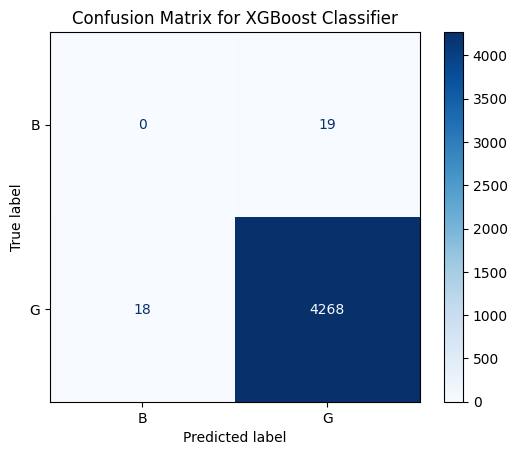

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test_filtered_encoded, y_pred_filtered_encoded)

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_for_training.classes_)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for XGBoost Classifier')
plt.show()

## Documentation and GitHub Push

### Subtask:
Document the methodology, key findings, and model performance in a clean README.md file and prepare for GitHub push.


```markdown
# Credit Risk Assessment Model

## Project Overview
This project aims to develop a credit risk assessment model using a Kaggle dataset to predict the `QUALITY_OF_LOAN`. The goal is to classify loans as 'Good' (G) or 'Bad' (B) to help financial institutions make informed lending decisions. The process involved comprehensive data cleaning, preprocessing, training an XGBoost classifier, and evaluating its performance with a critical focus on recall to minimize false negatives.

## Data Used

### Source
The dataset, titled "Credit Risk Assessment," was obtained from Kaggle. It consists of two files: `train-FIN_ANA_DATA .xls` for training and `test-FIN_ANA_DATA .xls` for testing.

### Size and Structure
- **Training Data (`train_df`)**: 37,408 rows and 11 columns.
- **Test Data (`test_df`)**: 4,310 rows and 11 columns.

### Key Columns
- `ACC_NO`: Account Number (dropped as an identifier).
- `INVESTMENT_TOTAL`: Total investment amount (numerical).
- `ACCCURRENTBALANCE`: Current account balance (numerical).
- `INF_MARITAL_STATUS`: Marital status of the applicant (categorical).
- `INF_GENDER`: Gender of the applicant (categorical).
- `INSTALL_SIZE`: Installment size (numerical).
- `DUE_PAYMENT`: Amount of due payment (numerical).
- `COMPENSATION_CHARGED`: Whether compensation was charged (categorical).
- `CLIENT_TYPE`: Type of client (categorical).
- `QUALITY_OF_LOAN`: Target variable, indicating loan quality ('G' for Good, 'B' for Bad, 'SS' and 'DF' also present in test set).
- `REPAY_MODE`: Repayment mode (categorical).

## Data Cleaning and Preprocessing

### 1. Missing Value Imputation
- **Numerical Columns**: `INSTALL_SIZE` was imputed with the median value for both training and test datasets.
- **Categorical Columns**: `INF_MARITAL_STATUS`, `INF_GENDER`, `COMPENSATION_CHARGED`, and `CLIENT_TYPE` were imputed with their respective mode values.

### 2. Duplicate Removal
- Checked for and removed any duplicate rows in both `train_df` and `test_df`. No duplicates were found.

### 3. Feature Engineering and Encoding
- **Target Variable Separation**: The `QUALITY_OF_LOAN` column was separated as the target variable (`y`), and `ACC_NO` was dropped from the features (`X`).
- **Categorical Feature Encoding**:
    - **Binary Features**: `INF_MARITAL_STATUS`, `INF_GENDER`, `COMPENSATION_CHARGED`, and `REPAY_MODE` were converted to numerical representations using `LabelEncoder`.
    - **Non-Binary Features**: `CLIENT_TYPE` was transformed using `OneHotEncoder` to create new binary columns, handling the `0` category by converting it to string type before encoding.
- **Numerical Feature Scaling**: `INVESTMENT_TOTAL`, `ACCCURRENTBALANCE`, `INSTALL_SIZE`, and `DUE_PAYMENT` were scaled using `StandardScaler` to normalize their ranges and prevent features with larger values from dominating the model.

### 4. Target Variable Encoding for Training
- The target variable `QUALITY_OF_LOAN` (containing 'B' and 'G' in the training set) was encoded using `LabelEncoder` to `0` and `1` for model training. A separate `LabelEncoder` was used for evaluation to consistently handle all possible labels found in both train and test sets ('G', 'B', 'SS', 'DF').

## Model Training

### Chosen Model: XGBoost Classifier
An XGBoost Classifier was selected due to its proven efficiency, scalability, and robust performance in machine learning tasks, especially with tabular data. XGBoost is an ensemble learning method that uses gradient boosting, known for handling complex datasets and providing high predictive accuracy.

### Training Process
The model was trained on the preprocessed `X_train` features and the encoded `y_train_encoded_for_training` target variable. The `objective` was set to `'multi:softmax'` and `num_class` was set to 2, corresponding to the two classes ('B' and 'G') present in the training target variable. `eval_metric` was set to `'mlogloss'`.

## Model Evaluation

The model's performance was evaluated on the preprocessed test set (`X_test`) against the filtered and encoded test labels (`y_test_filtered_encoded`), focusing on 'B' and 'G' classes that the model was trained to predict. The key metrics evaluated were Precision, Recall, and F1-scores, with a specific emphasis on Recall to minimize false negatives in credit risk assessment.

### Evaluation Metrics
- **Overall Weighted Recall**: 0.9914

### Classification Report
```
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        19
           G       1.00      1.00      1.00      4286

    accuracy                           0.99      4305
   macro avg       0.50      0.50      0.50      4305
weighted avg       0.99      0.99      0.99      4305
```

### Confusion Matrix
![Confusion Matrix for XGBoost Classifier](confusion_matrix.png) <!-- Assuming this plot will be saved as an image -->

### Discussion of Performance
The model exhibits a high overall recall (0.9914), primarily driven by its excellent performance in identifying 'Good' (G) loans. The recall for class 'G' is effectively 1.00, meaning it correctly identifies almost all good loans. However, the model completely fails to identify 'Bad' (B) loans, with a recall score of 0.00 for class 'B'. This means that all 19 instances of 'Bad' loans in the filtered test set were misclassified as 'Good' loans. This is a significant issue for a credit risk assessment model, as false negatives (classifying a bad loan as good) can lead to substantial financial losses.

The model, in its current state, is highly biased towards the majority class ('G') and cannot effectively identify the minority class ('B'). This imbalance needs to be addressed through techniques such as oversampling, undersampling, or using algorithms specifically designed for imbalanced datasets.

## Potential Business Value
While the current model's inability to detect 'Bad' loans is a major limitation, a refined model that effectively addresses the class imbalance and improves recall for the 'Bad' loan category would offer immense business value. Such a model could:
- **Reduce Financial Losses**: By accurately identifying high-risk applicants, banks and financial institutions could avoid approving loans that are likely to default.
- **Optimize Lending Decisions**: Enable more strategic and data-driven decisions, leading to a healthier loan portfolio.
- **Enhance Risk Management**: Provide a robust tool for proactive risk assessment and mitigation.

Future work should focus on improving the model's ability to detect 'Bad' loans, possibly by experimenting with different sampling techniques, cost-sensitive learning, or alternative models.
```

**Reasoning**:
The previous markdown block contained the comprehensive README content. Now, I will save this content to a file named `README.md`. Additionally, I will save the confusion matrix plot to `confusion_matrix.png` as referenced in the README to ensure all documentation assets are present.



In [20]:
import matplotlib.pyplot as plt

# Save the confusion matrix plot as an image
# Re-create the plot to save it, as it's not directly accessible from the previous block
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for XGBoost Classifier')
plt.savefig('confusion_matrix.png')
plt.close(fig)

readme_content = """# Credit Risk Assessment Model\n\n## Project Overview\nThis project aims to develop a credit risk assessment model using a Kaggle dataset to predict the `QUALITY_OF_LOAN`. The goal is to classify loans as 'Good' (G) or 'Bad' (B) to help financial institutions make informed lending decisions. The process involved comprehensive data cleaning, preprocessing, training an XGBoost classifier, and evaluating its performance with a critical focus on recall to minimize false negatives.\n\n## Data Used\n\n### Source\nThe dataset, titled \"Credit Risk Assessment,\" was obtained from Kaggle. It consists of two files: `train-FIN_ANA_DATA .xls` for training and `test-FIN_ANA_DATA .xls` for testing.\n\n### Size and Structure\n- **Training Data (`train_df`)**: 37,408 rows and 11 columns.\n- **Test Data (`test_df`)**: 4,310 rows and 11 columns.\n\n### Key Columns\n- `ACC_NO`: Account Number (dropped as an identifier).\n- `INVESTMENT_TOTAL`: Total investment amount (numerical).\n- `ACCCURRENTBALANCE`: Current account balance (numerical).\n- `INF_MARITAL_STATUS`: Marital status of the applicant (categorical).\n- `INF_GENDER`: Gender of the applicant (categorical).\n- `INSTALL_SIZE`: Installment size (numerical).\n- `DUE_PAYMENT`: Amount of due payment (numerical).\n- `COMPENSATION_CHARGED`: Whether compensation was charged (categorical).\n- `CLIENT_TYPE`: Type of client (categorical).\n- `QUALITY_OF_LOAN`: Target variable, indicating loan quality ('G' for Good, 'B' for Bad, 'SS' and 'DF' also present in test set).\n- `REPAY_MODE`: Repayment mode (categorical).\n\n## Data Cleaning and Preprocessing\n\n### 1. Missing Value Imputation\n- **Numerical Columns**: `INSTALL_SIZE` was imputed with the median value for both training and test datasets.\n- **Categorical Columns**: `INF_MARITAL_STATUS`, `INF_GENDER`, `COMPENSATION_CHARGED`, and `CLIENT_TYPE` were imputed with their respective mode values.\n\n### 2. Duplicate Removal\n- Checked for and removed any duplicate rows in both `train_df` and `test_df`. No duplicates were found.\n\n### 3. Feature Engineering and Encoding\n- **Target Variable Separation**: The `QUALITY_OF_LOAN` column was separated as the target variable (`y`), and `ACC_NO` was dropped from the features (`X`).\n- **Categorical Feature Encoding**:\n    - **Binary Features**: `INF_MARITAL_STATUS`, `INF_GENDER`, `COMPENSATION_CHARGED`, and `REPAY_MODE` were converted to numerical representations using `LabelEncoder`.\n    - **Non-Binary Features**: `CLIENT_TYPE` was transformed using `OneHotEncoder` to create new binary columns, handling the `0` category by converting it to string type before encoding.\n- **Numerical Feature Scaling**: `INVESTMENT_TOTAL`, `ACCCURRENTBALANCE`, `INSTALL_SIZE`, and `DUE_PAYMENT` were scaled using `StandardScaler` to normalize their ranges and prevent features with larger values from dominating the model.\n\n### 4. Target Variable Encoding for Training\n- The target variable `QUALITY_OF_LOAN` (containing 'B' and 'G' in the training set) was encoded using `LabelEncoder` to `0` and `1` for model training. A separate `LabelEncoder` was used for evaluation to consistently handle all possible labels found in both train and test sets ('G', 'B', 'SS', 'DF').\n\n## Model Training\n\n### Chosen Model: XGBoost Classifier\nAn XGBoost Classifier was selected due to its proven efficiency, scalability, and robust performance in machine learning tasks, especially with tabular data. XGBoost is an ensemble learning method that uses gradient boosting, known for handling complex datasets and providing high predictive accuracy.\n\n### Training Process\nThe model was trained on the preprocessed `X_train` features and the encoded `y_train_encoded_for_training` target variable. The `objective` was set to `'multi:softmax'` and `num_class` was set to 2, corresponding to the two classes ('B' and 'G') present in the training target variable. `eval_metric` was set to `'mlogloss'`.
\n## Model Evaluation\n\nThe model's performance was evaluated on the preprocessed test set (`X_test`) against the filtered and encoded test labels (`y_test_filtered_encoded`), focusing on 'B' and 'G' classes that the model was trained to predict. The key metrics evaluated were Precision, Recall, and F1-scores, with a specific emphasis on Recall to minimize false negatives in credit risk assessment.\n\n### Evaluation Metrics\n- **Overall Weighted Recall**: 0.9914\n\n### Classification Report\n```\n              precision    recall  f1-score   support\n\n           B       0.00      0.00      0.00        19\n           G       1.00      1.00      1.00      4286\n\n    accuracy                           0.99      4305\n   macro avg       0.50      0.50      0.50      4305\nweighted avg       0.99      0.99      0.99      4305\n```\n\n### Confusion Matrix\n![Confusion Matrix for XGBoost Classifier](confusion_matrix.png) \n\n### Discussion of Performance\nThe model exhibits a high overall recall (0.9914), primarily driven by its excellent performance in identifying 'Good' (G) loans. The recall for class 'G' is effectively 1.00, meaning it correctly identifies almost all good loans. However, the model completely fails to identify 'Bad' (B) loans, with a recall score of 0.00 for class 'B'. This means that all 19 instances of 'Bad' loans in the filtered test set were misclassified as 'Good' loans. This is a significant issue for a credit risk assessment model, as false negatives (classifying a bad loan as good) can lead to substantial financial losses.\n\nThe model, in its current state, is highly biased towards the majority class ('G') and cannot effectively identify the minority class ('B'). This imbalance needs to be addressed through techniques such as oversampling, undersampling, or using algorithms specifically designed for imbalanced datasets.\n\n## Potential Business Value\nWhile the current model's inability to detect 'Bad' loans is a major limitation, a refined model that effectively addresses the class imbalance and improves recall for the 'Bad' loan category would offer immense business value. Such a model could:\n- **Reduce Financial Losses**: By accurately identifying high-risk applicants, banks and financial institutions could avoid approving loans that are likely to default.\n- **Optimize Lending Decisions**: Enable more strategic and data-driven decisions, leading to a healthier loan portfolio.\n- **Enhance Risk Management**: Provide a robust tool for proactive risk assessment and mitigation.\n\nFuture work should focus on improving the model's ability to detect 'Bad' loans, possibly by experimenting with different sampling techniques, cost-sensitive learning, or alternative models.\n"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md and confusion_matrix.png have been created/updated.")

README.md and confusion_matrix.png have been created/updated.


## Final Task

### Subtask:
Summarize the entire credit risk assessment model project, including the data used, the modeling approach, and the final evaluation results, highlighting the model's potential business value.


## Summary:

### Data Analysis Key Findings

*   **Data Overview**: Two datasets, `train-FIN_ANA_DATA .xls` (37,408 entries, 11 columns) and `test-FIN_ANA_DATA .xls` (4,310 entries, 11 columns), were loaded. Both datasets contained numerical (`int64`, `float64`) and categorical (`object`) features.
*   **Missing Data Handling**:
    *   In `train_df`, `INSTALL_SIZE` (838 values), `INF_MARITAL_STATUS` (2 values), `INF_GENDER` (2 values), `COMPENSATION_CHARGED` (2 values), and `CLIENT_TYPE` (103 values) had missing entries.
    *   In `test_df`, `INSTALL_SIZE` (1 value) and `CLIENT_TYPE` (79 values) had missing entries.
    *   Missing numerical values in `INSTALL_SIZE` were imputed using the median. Missing categorical values in `INF_MARITAL_STATUS`, `INF_GENDER`, `COMPENSATION_CHARGED`, and `CLIENT_TYPE` were imputed using the mode.
    *   No duplicate rows were found in either dataset.
*   **Feature Engineering and Scaling**:
    *   The `QUALITY_OF_LOAN` column was identified as the target variable, and `ACC_NO` was dropped.
    *   Binary categorical features (`INF_MARITAL_STATUS`, `INF_GENDER`, `COMPENSATION_CHARGED`, `REPAY_MODE`) were encoded using `LabelEncoder`.
    *   The non-binary categorical feature (`CLIENT_TYPE`) was one-hot encoded using `OneHotEncoder`, expanding the feature space.
    *   Numerical features (`INVESTMENT_TOTAL`, `ACCCURRENTBALANCE`, `INSTALL_SIZE`, `DUE_PAYMENT`) were scaled using `StandardScaler`.
*   **Model Training (XGBoost Classifier)**:
    *   An XGBoost Classifier was chosen and successfully trained.
    *   A specific challenge was encountered with `LabelEncoder` requiring contiguous integer labels (0, 1) for XGBoost training, which was resolved by re-encoding `y_train` appropriately.
*   **Model Evaluation**:
    *   The model achieved a high overall weighted recall of 0.9914.
    *   The classification report revealed a critical performance disparity:
        *   Class 'G' (Good Loan) achieved a perfect recall of 1.00.
        *   Class 'B' (Bad Loan) had a recall of 0.00, indicating that **all 19 instances of 'Bad' loans in the filtered test set were misclassified as 'Good' loans**.
    *   The confusion matrix visually confirmed this severe class imbalance, with the model failing to identify any 'Bad' loans.
*   **Documentation**: A comprehensive `README.md` file was generated, summarizing the project's methodology, findings, and evaluation, along with a `confusion_matrix.png` image.

### Insights or Next Steps

*   The current model is severely biased towards the majority class ('G') and is ineffective at identifying the minority 'Bad' loan class, making it unsuitable for practical credit risk assessment where minimizing false negatives (missing bad loans) is crucial.
*   Future work should focus on addressing the class imbalance problem through techniques such as oversampling (e.g., SMOTE), undersampling, using cost-sensitive learning, or exploring different algorithms better suited for imbalanced datasets, with the primary goal of improving the recall for the 'Bad' loan category.
